# 🐾 Animal Faces Image Classification
**Author:** Zulqarnain  
**Framework:** TensorFlow / Keras  
**Task:** Multi-class Image Classification (Cat / Dog / Wild)

---

# 📑 Table of Contents

<a href="#animal-faces-image-classification">1. Animal Faces Image Classification</a><br>
<a href="#dataset-overview">2. Dataset Overview</a><br>
<a href="#motivation">3. Motivation</a><br>
<a href="#import-libraries">4. Import Libraries</a><br>
<a href="#download-dataset">5. Download Dataset</a><br>
<a href="#prepare-data">6. Prepare Data</a><br>
<a href="#visualize-sample-images">7. Visualize Sample Images</a><br>
<a href="#define-model-training-function">8. Define Model Training Function</a><br>
<a href="#plot-training-history">9. Plot Training History</a><br>
<a href="#evaluate-model">10. Evaluate Model</a><br>
<a href="#show-predictions">11. Show Predictions</a><br>
<a href="#train-multiple-models">12. Train Multiple Models</a><br>
<a href="#compare-model-accuracy">13. Compare Model Accuracy</a><br>
<a href="#final-predictions">14. Show Final Predictions</a><br>


<div id="dataset-overview" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>📌 Dataset Overview</h3>
<p>The <b>AFHQ (Animal Faces-HQ)</b> dataset consists of 16,130 high-quality images (512×512 resolution) divided into 3 classes:</p>
<ul>
<li>Cat (~5k images)</li>
<li>Dog (~5k images)</li>
<li>Wildlife (~5k images)</li>
</ul>
<p>This dataset is ideal for transfer learning and image classification tasks.</p>
</div>


<div id="motivation" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>🎯 Motivation</h3>
<ul>
<li>Training CNNs from scratch requires large datasets and high compute.</li>
<li><b>Transfer Learning</b> allows leveraging pre-trained models to:</li>
<ul>
<li>⚡ Reduce training time</li>
<li>📈 Improve accuracy</li>
<li>🛡️ Prevent overfitting</li>
</ul>
</ul>
</div>


<div id="import-libraries" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>📦 Import Libraries</h3>
</div>


In [55]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import (
    VGG16, MobileNetV2, ResNet50, EfficientNetB0
)


<div id="download-dataset" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>📥 Download Dataset</h3>
</div>


In [56]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Path to dataset files:", path)

data_Dir=os.path.join(path,'afhq')

Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces


<div id="prepare-data" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>🗂️ Prepare Data</h3>
</div>


In [57]:
train_dir=os.path.join(data_Dir,'train')
val_dir=os.path.join(data_Dir,'val')

image_size=(224,224)
batch_size=32

train_ds=image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True,
    label_mode='int'


)

validation_data=image_dataset_from_directory(
    val_dir,
    image_size=image_size,
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True,
    label_mode='int'


)

Found 14630 files belonging to 3 classes.
Found 1500 files belonging to 3 classes.


In [58]:
val_size = int(0.8 * tf.data.experimental.cardinality(validation_data).numpy())
test_size = tf.data.experimental.cardinality(validation_data).numpy() - val_size

val_ds = validation_data.take(val_size)
test_ds = validation_data.skip(val_size)

classes=train_ds.class_names

<div id="visualize-sample-images" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>🔍 Visualize Sample Images</h3>
</div>


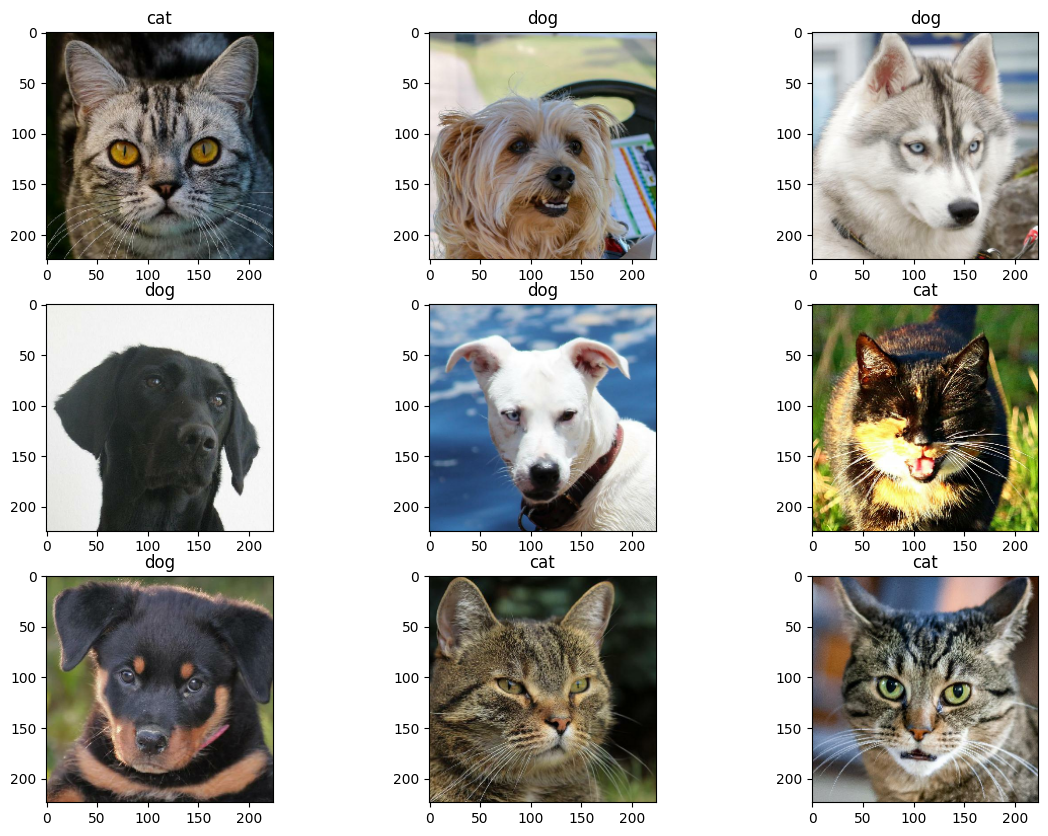

In [59]:
for image,label in train_ds.take(1):
  plt.figure(figsize=(14,10))
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(classes[label[i]])
  plt.show()


<div id="define-model-training-function" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>⚙️ Define Model Training Function</h3>
</div>


In [60]:
def train_model(model_fn, model_name, train_ds, val_ds, epochs=10):
    base_model = model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    return model, history.history


<div id="plot-training-history" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>📈 Plot Training History Function</h3>
</div>


In [61]:
def plot_training_history(history, model_name):
    epochs = range(1, len(history['accuracy']) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{model_name}\nAccuracy')

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, history['loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{model_name}\nLoss')

    plt.show()


<div id="evaluate-model" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>📊 Evaluate Model</h3>
</div>


In [62]:
def evaluate_model(model, test_ds, class_names, title):
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_pred = np.argmax(model.predict(test_ds), axis=1)

    print(f"\n📊 Classification Report ({title})\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


<div id="show-predictions" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>🔮 Show Predictions Function</h3>
</div>


In [ ]:
def show_predictions(models_dict, dataset, class_names, num_images=5):
    for name, model in models_dict.items():
        print(f"\n🔹 Predictions for {name}\n")
        plt.figure(figsize=(15,5))
        images_shown = 0

        for images, labels in dataset.take(1):  # Take one batch
            preds = np.argmax(model.predict(images), axis=1)

            for i in range(len(images)):
                if images_shown >= num_images:
                    break
                plt.subplot(1, num_images, images_shown+1)
                plt.imshow(images[i].numpy().astype('uint8'))
                plt.title(f"Pred: {class_names[preds[i]]}\nActual: {class_names[labels[i]]}")
                plt.axis('off')
                images_shown += 1
        plt.show()


<div id="train-multiple-models" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>🚀 Train Multiple Models</h3>
</div>



🚀 Training VGG16

Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 84s 178ms/step - accuracy: 0.9475 - loss: 0.5068 - val_accuracy: 0.9932 - val_loss: 0.0728
Epoch 2/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 78s 171ms/step - accuracy: 0.9930 - loss: 0.0441 - val_accuracy: 0.9890 - val_loss: 0.1135
Epoch 3/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 82s 171ms/step - accuracy: 0.9914 - loss: 0.0489 - val_accuracy: 0.9966 - val_loss: 0.0540
Epoch 4/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 78s 171ms/step - accuracy: 0.9937 - loss: 0.0422 - val_accuracy: 0.9958 - val_loss: 0.0504
Epoch 5/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 78s 171ms/step - accuracy: 0.9966 - loss: 0.0130 - val_accuracy: 0.9916 - val_loss: 0.0449


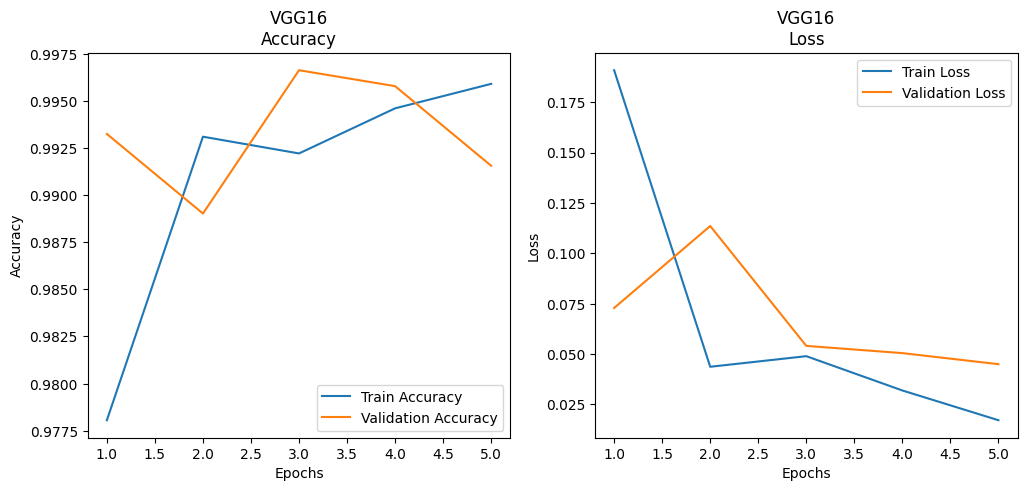


🚀 Training MobileNetV2

Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.7209 - loss: 0.7283 - val_accuracy: 0.8218 - val_loss: 0.4459
Epoch 2/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.8417 - loss: 0.4015 - val_accuracy: 0.8285 - val_loss: 0.4658
Epoch 3/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.8585 - loss: 0.3495 - val_accuracy: 0.8446 - val_loss: 0.4038
Epoch 4/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.8683 - loss: 0.3293 - val_accuracy: 0.8319 - val_loss: 0.4511
Epoch 5/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.8790 - loss: 0.2986 - val_accuracy: 0.8421 - val_loss: 0.4147


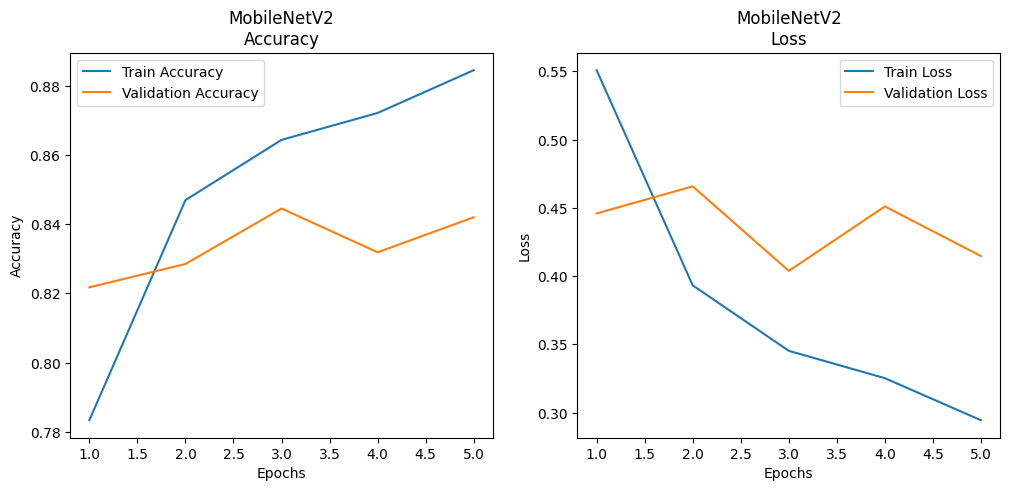


🚀 Training ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 63s 109ms/step - accuracy: 0.9713 - loss: 0.0845 - val_accuracy: 0.9890 - val_loss: 0.0295
Epoch 2/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9934 - loss: 0.0209 - val_accuracy: 0.9932 - val_loss: 0.0157
Epoch 3/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9974 - loss: 0.0099 - val_accuracy: 0.9916 - val_loss: 0.0309
Epoch 4/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9982 - loss: 0.0048 - val_accuracy: 0.9983 - val_loss: 0.0087
Epoch 5/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9975 - val_loss: 0.0107


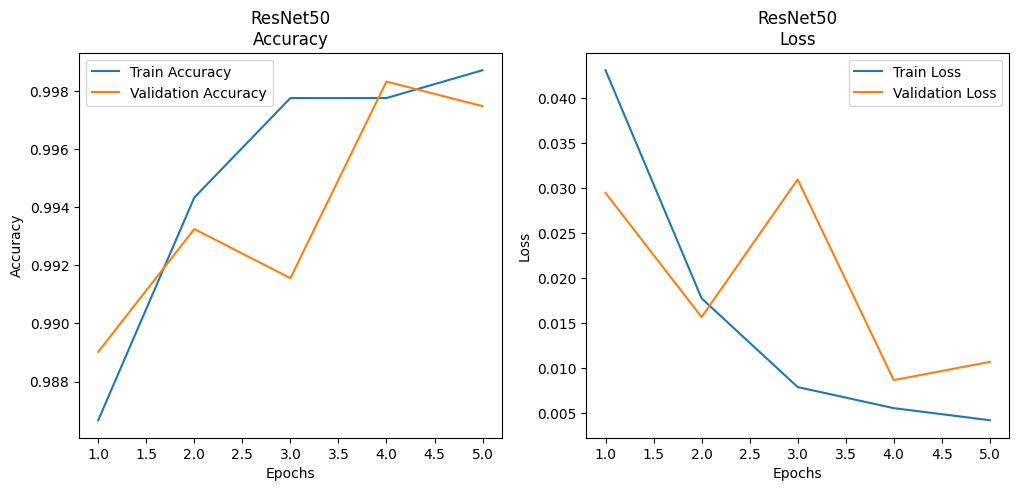


🚀 Training EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 77s 118ms/step - accuracy: 0.9805 - loss: 0.0468 - val_accuracy: 0.9975 - val_loss: 0.0143
Epoch 2/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.9976 - loss: 0.0071 - val_accuracy: 0.9992 - val_loss: 0.0121
Epoch 3/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.9986 - loss: 0.0054 - val_accuracy: 0.9992 - val_loss: 0.0169
Epoch 4/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - accuracy: 0.9989 - loss: 0.0027 - val_accuracy: 0.9983 - val_loss: 0.0184
Epoch 5/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step - accuracy: 0.9994 - loss: 0.0016 - val_accuracy: 0.9992 - val_loss: 0.0178


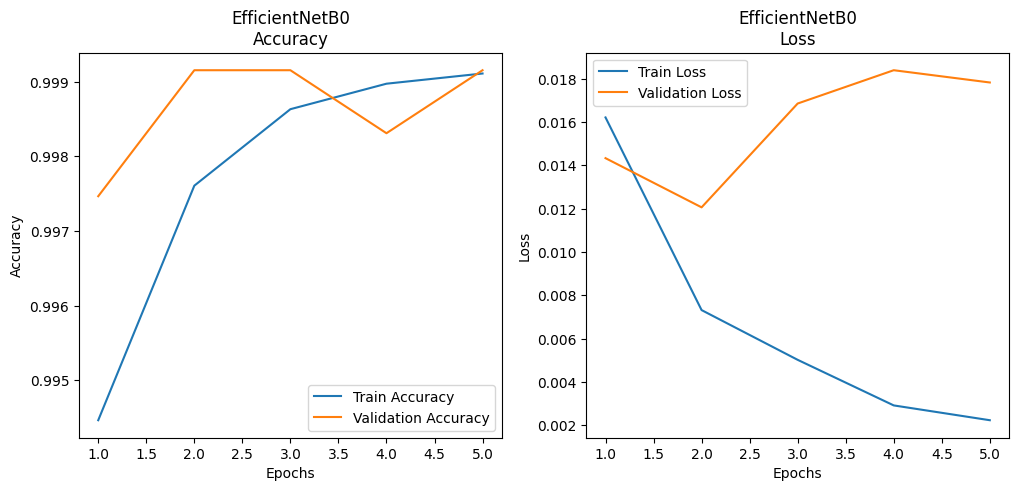

In [63]:
models = {
    "VGG16": VGG16,
    "MobileNetV2": MobileNetV2,
    "ResNet50": ResNet50,
    "EfficientNetB0": EfficientNetB0
}

histories = {}
trained_models = {}
final_accuracies = {}

for name, model_fn in models.items():
    print(f"\n🚀 Training {name}\n")
    model, hist = train_model(model_fn, name, train_ds, val_ds, epochs=5)
    trained_models[name] = model
    histories[name] = hist
    final_accuracies[name] = hist['val_accuracy'][-1]

    # Pass the string model name, not the model object
    plot_training_history(hist, name)


10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step

📊 Classification Report (VGG16)

              precision    recall  f1-score   support

         cat       0.31      0.33      0.32       109
         dog       0.25      0.27      0.26        96
        wild       0.38      0.32      0.35       111

    accuracy                           0.31       316
   macro avg       0.31      0.31      0.31       316
weighted avg       0.31      0.31      0.31       316



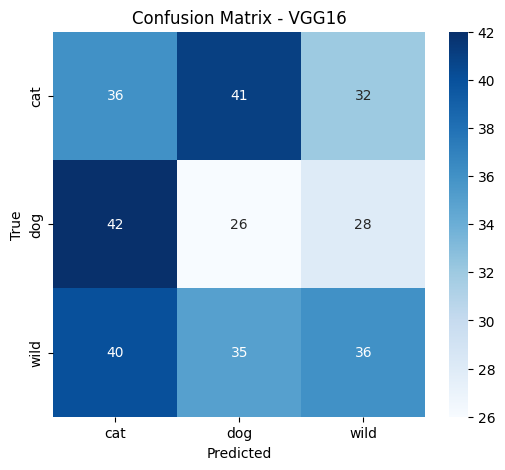

10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

📊 Classification Report (MobileNetV2)

              precision    recall  f1-score   support

         cat       0.38      0.38      0.38       112
         dog       0.30      0.26      0.28        93
        wild       0.35      0.38      0.36       111

    accuracy                           0.34       316
   macro avg       0.34      0.34      0.34       316
weighted avg       0.34      0.34      0.34       316



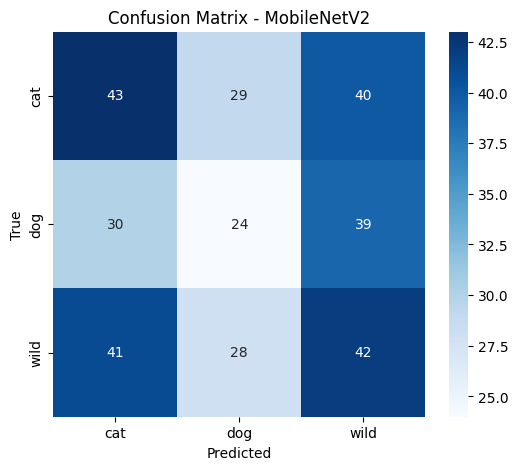

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 714ms/step

📊 Classification Report (ResNet50)

              precision    recall  f1-score   support

         cat       0.37      0.34      0.35       112
         dog       0.33      0.32      0.32        99
        wild       0.33      0.36      0.35       105

    accuracy                           0.34       316
   macro avg       0.34      0.34      0.34       316
weighted avg       0.34      0.34      0.34       316



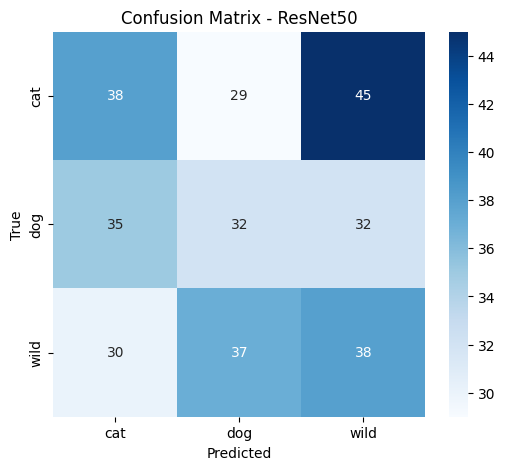

10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

📊 Classification Report (EfficientNetB0)

              precision    recall  f1-score   support

         cat       0.36      0.40      0.38       106
         dog       0.32      0.32      0.32        96
        wild       0.34      0.31      0.32       114

    accuracy                           0.34       316
   macro avg       0.34      0.34      0.34       316
weighted avg       0.34      0.34      0.34       316



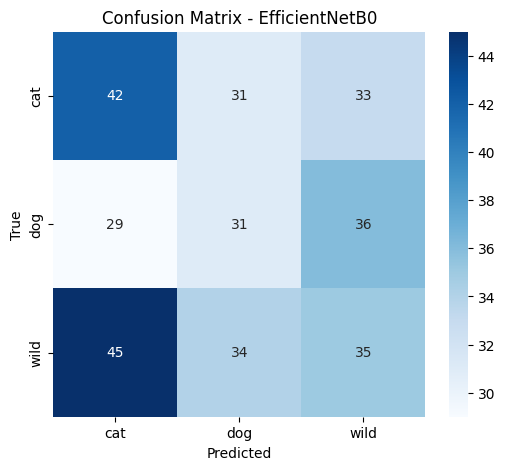

In [64]:
class_names = ['cat', 'dog', 'wild']

for name, model in trained_models.items():
    evaluate_model(model, test_ds, class_names, name)


<div id="compare-model-accuracy" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>📊 Compare Model Accuracy</h3>
</div>


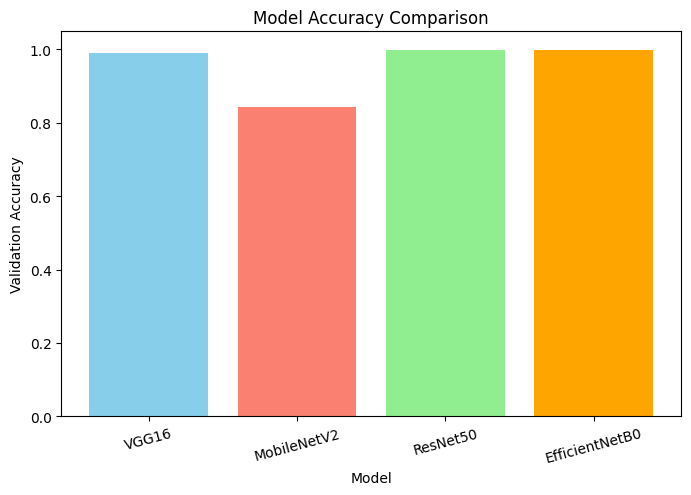

In [68]:
colors = ['skyblue', 'salmon', 'lightgreen', 'orange']
plt.figure(figsize=(8,5))
plt.bar(final_accuracies.keys(), final_accuracies.values(), color=colors)
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.show()


<div id="final-predictions" style="background-color:#f0f8ff; padding:15px; border-radius:10px;">
<h3>🔹 Final Predictions</h3>
</div>



🔹 Predictions for VGG16

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step


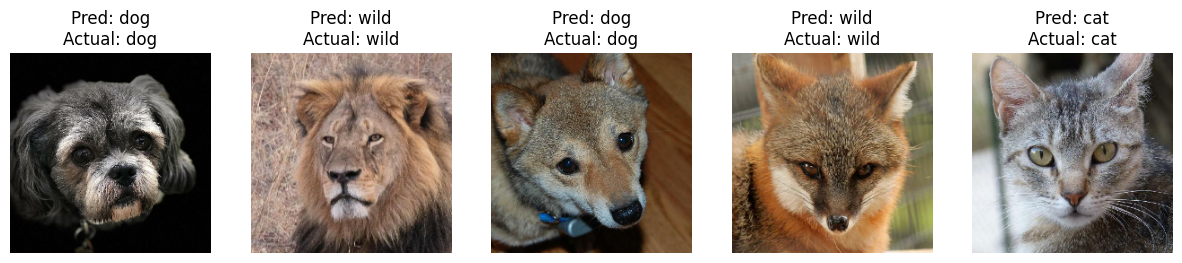


🔹 Predictions for MobileNetV2

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


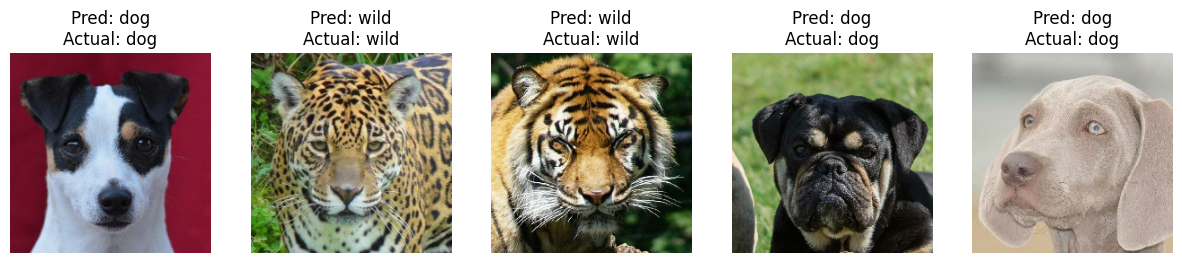


🔹 Predictions for ResNet50



1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


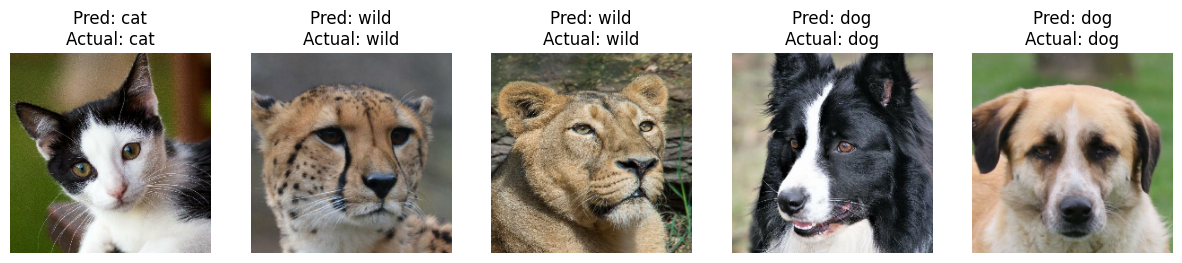


🔹 Predictions for EfficientNetB0



1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


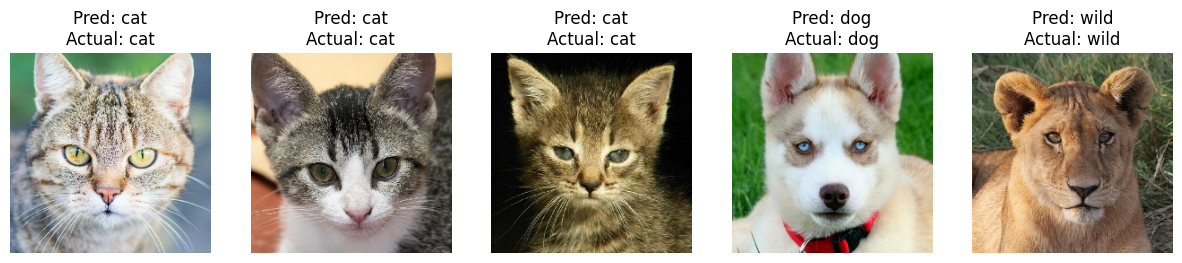

In [70]:
show_predictions(trained_models, test_ds, class_names, num_images=5)